In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [3]:
env = gym.make("FrozenLake-v1",
               desc=[
                   "FFSF",
                   "FHFH",
                   "FFFH",
                   "GHFF

],is_slippery=True)


num_states = env.observation_space.n
num_actions = env.action_space.n


In [5]:
# -------------------------------------------------
# Hyperparameters
# -------------------------------------------------

num_episodes = 10000
max_steps_per_episode = 100

alpha = 0.1
gamma = 0.99

# Variable epsilon
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.9995

In [7]:
# -------------------------------------------------
# Initialize Q-table
# -------------------------------------------------

Q = np.zeros((num_states, num_actions))



# -------------------------------------------------
# Epsilon-Greedy Action Selection
# -------------------------------------------------

def epsilon_greedy_action(state, epsilon):

    if np.random.random() < epsilon:
        # Exploration
        return env.action_space.sample()

    else:
        # Exploitation
        return np.argmax(Q[state])





In [8]:

# -------------------------------------------------
# SARSA Training
# -------------------------------------------------

episode_rewards = []

for episode in range(num_episodes):

    # Environment decides the initial state
    state, info = env.reset()

    # Select first action using current epsilon
    action = epsilon_greedy_action(state, epsilon)

    total_reward = 0

    for step in range(max_steps_per_episode):

        # Take action
        next_state, reward, terminated, truncated, info = env.step(action)

        total_reward += reward

        # If episode has not ended,
        # select next action using current policy
        if not terminated and not truncated:
            next_action = epsilon_greedy_action(
                next_state, epsilon
            )

            # SARSA target
            td_target = (
                reward
                + gamma * Q[next_state, next_action]
            )

        else:
            # No next action for terminal state
            next_action = None

            td_target = reward

        # SARSA update
        td_error = td_target - Q[state, action]

        Q[state, action] = (
            Q[state, action]
            + alpha * td_error
        )

        # Stop if episode is finished
        if terminated or truncated:
            break

        # Move to next state and action
        state = next_state
        action = next_action

    episode_rewards.append(total_reward)

    # -------------------------------------------------
    # Variable Epsilon Decay
    # -------------------------------------------------

    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )



In [9]:

# -------------------------------------------------
# State-Value Function and Policy
# -------------------------------------------------

state_values = np.max(Q, axis=1)

learned_policy = np.argmax(Q, axis=1)




In [10]:

# -------------------------------------------------
# Display Functions
# -------------------------------------------------

def print_value_function(values):

    print("\nEstimated State-Value Function:")

    print(
        np.round(
            values.reshape(4, 4),
            3
        )
    )


def print_policy(policy):

    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [
            action_symbols[action]
            for action in policy
        ]
    ).reshape(4, 4)

    print("\nLearned Policy:")
    print(policy_grid)



In [11]:

# -------------------------------------------------
# Output
# -------------------------------------------------

print("\nFinal Q-table:")

print(
    np.round(Q, 3)
)

print_value_function(state_values)

print_policy(learned_policy)

average_reward = np.mean(
    episode_rewards[-1000:]
)

print(
    "\nAverage reward over last 1000 episodes:",
    average_reward
)

print(
    "\nFinal epsilon:",
    epsilon
)





Final Q-table:
[[0.32  0.312 0.307 0.315]
 [0.194 0.188 0.172 0.29 ]
 [0.228 0.219 0.241 0.262]
 [0.138 0.194 0.18  0.255]
 [0.348 0.292 0.276 0.216]
 [0.    0.    0.    0.   ]
 [0.182 0.115 0.117 0.094]
 [0.    0.    0.    0.   ]
 [0.326 0.34  0.317 0.403]
 [0.37  0.449 0.387 0.3  ]
 [0.318 0.331 0.299 0.241]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.357 0.415 0.652 0.4  ]
 [0.655 0.781 0.654 0.667]
 [0.    0.    0.    0.   ]]

Estimated State-Value Function:
[[0.32  0.29  0.262 0.255]
 [0.348 0.    0.182 0.   ]
 [0.403 0.449 0.331 0.   ]
 [0.    0.652 0.781 0.   ]]

Learned Policy:
[['L' 'U' 'U' 'U']
 ['L' 'L' 'L' 'L']
 ['U' 'D' 'D' 'L']
 ['L' 'R' 'D' 'L']]

Average reward over last 1000 episodes: 0.494

Final epsilon: 0.05


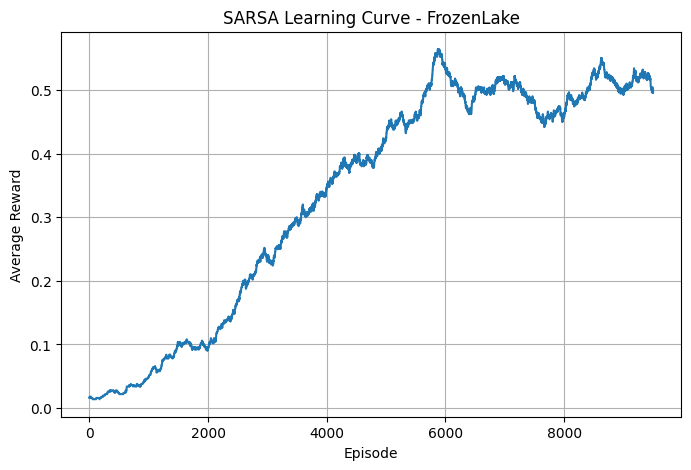

In [12]:

# -------------------------------------------------
# Plot Learning Curve
# -------------------------------------------------

window = 500

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 5))

plt.plot(moving_average)

plt.xlabel("Episode")
plt.ylabel("Average Reward")

plt.title(
    "SARSA Learning Curve - FrozenLake"
)

plt.grid(True)

plt.show()

env.close()